In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler 

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import warnings
warnings.filterwarnings('ignore')

In [23]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
X = data.data
y = data.target

In [24]:
# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Normalize
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [25]:
model = keras.Sequential([
    layers.Dense(16, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dense(8, activation='relu'),
    layers.Dense(1, activation='sigmoid')  # Binary classification
])

In [26]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [27]:
history = model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.8269 - loss: 0.5409 - val_accuracy: 0.8022 - val_loss: 0.5226
Epoch 2/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8764 - loss: 0.4756 - val_accuracy: 0.9121 - val_loss: 0.4605
Epoch 3/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9203 - loss: 0.4137 - val_accuracy: 0.9121 - val_loss: 0.4013
Epoch 4/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9368 - loss: 0.3591 - val_accuracy: 0.9341 - val_loss: 0.3504
Epoch 5/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9423 - loss: 0.3125 - val_accuracy: 0.9341 - val_loss: 0.3080
Epoch 6/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9423 - loss: 0.2732 - val_accuracy: 0.9451 - val_loss: 0.2723
Epoch 7/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9451 - loss: 0.2392 - val_accuracy: 0.9451 - val_loss: 0.2422
Epoch 8/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9533 - loss: 0.2092 - val_accuracy: 0.9451 - val_lo

In [28]:
loss, accuracy = model.evaluate(X_test, y_test)
print("Accuracy:", accuracy)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9649 - loss: 0.1067 
Accuracy: 0.9649122953414917


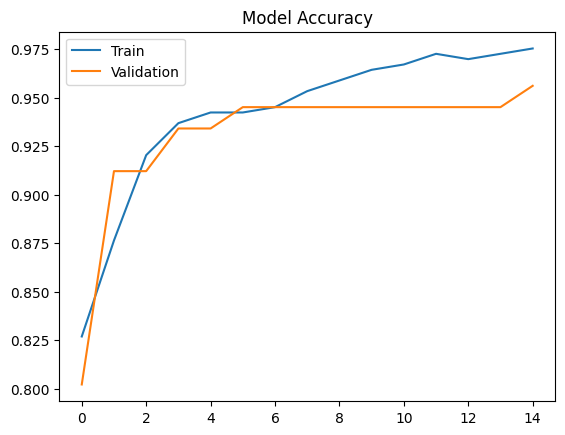

: 

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['Train', 'Validation'])
plt.title('Model Accuracy')
plt.show()